# Deep Learning — Assignment 1
**Laser Time-Series Forecasting**

Instructor: Siamak Mehrkanoon · Due: 08/05/26

**Group members:** *(fill in names + student IDs)*

---

### Tasks
- **(a)** Choose & motivate a neural-network model. Train it for one-step-ahead prediction. Scale data before training and unscale predictions.
- **(b)** Tune the lookback window `k` (number of past steps).
- **(c)** Use the trained model to recursively predict the next 200 points.
- **(d)** On 8 May, evaluate against the released test set with MAE, MSE, and a comparison plot.

### Models compared
| # | Model | Role |
|---|-------|------|
| 1 | Linear Regression | non-NN baseline |
| 2 | 1D-CNN | local temporal patterns |
| 3 | LSTM | sequential / gated memory |
| 4 | **CNN-LSTM** | **primary model** — local features + memory |


In [1]:
# ============================================================
# SECTION 0 — Imports & setup
# ============================================================
import os
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from IPython.display import display, HTML

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')
print('All libraries loaded.')


Device  : cpu
PyTorch : 2.10.0+cpu
All libraries loaded.


## 1. Load & explore the dataset
The training file `Xtrain.mat` contains a single 1D laser-intensity time series.

Total points : 1000
Min          : 2.00
Max          : 255.00
Mean         : 59.89
Std          : 46.85


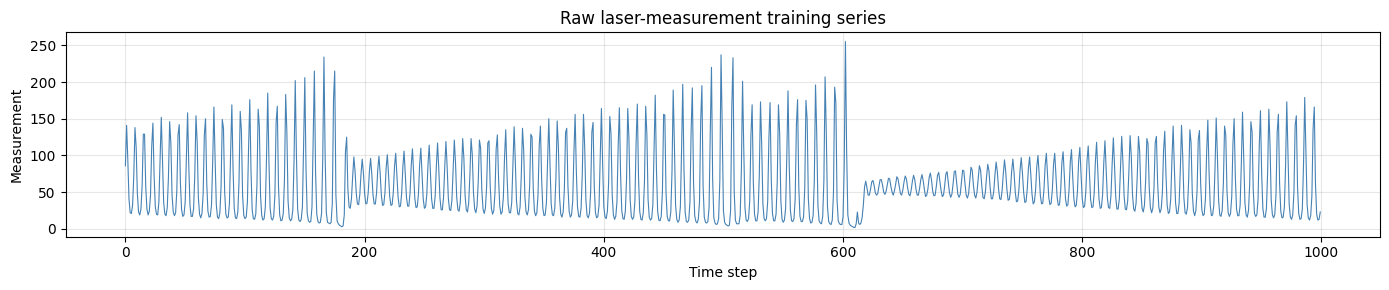

In [2]:
# ============================================================
# SECTION 1 — Load & explore the dataset
# Place Xtrain.mat next to the notebook, or update the path below.
# ============================================================
DATA_PATH = "/kaggle/input/datasets/ravinarsimha/xtrain1/Xtrain.mat"
data   = scipy.io.loadmat(DATA_PATH)

# The variable inside the .mat file is named 'Xtrain'
series = data["Xtrain"].flatten().astype(np.float32)

print(f'Total points : {len(series)}')
print(f'Min          : {series.min():.2f}')
print(f'Max          : {series.max():.2f}')
print(f'Mean         : {series.mean():.2f}')
print(f'Std          : {series.std():.2f}')

plt.figure(figsize=(14, 3))
plt.plot(series, color='steelblue', linewidth=0.8)
plt.title('Raw laser-measurement training series')
plt.xlabel('Time step'); plt.ylabel('Measurement')
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('00_raw_signal.png', dpi=150)
plt.show()


## 2. Scale the data
We use min-max scaling to `[0, 1]`.
The min/max are computed **only from the training series** so the scaling is reproducible at test time.
We also keep an `unscale` helper so predictions can be reported in the original measurement units.

In [3]:
# ============================================================
# SECTION 2 — Min-max scaling to [0, 1]
# ============================================================
data_min = series.min()
data_max = series.max()

def scale(x):
    return (x - data_min) / (data_max - data_min)

def unscale(x):
    return x * (data_max - data_min) + data_min

series_scaled = scale(series)
print(f'Scaled min: {series_scaled.min():.4f}   max: {series_scaled.max():.4f}')


Scaled min: 0.0000   max: 1.0000


## 3. Sliding-window builder
Convert the 1D series into supervised `(X, y)` pairs:

```
X[i] = series[i : i+k]      (k consecutive past values)
y[i] = series[i + k]        (the very next value)
```

In [4]:
# ============================================================
# SECTION 3 — Sliding-window builder
# ============================================================
def make_windows(series, k):
    """Return arrays X (n, k) and y (n,) of one-step-ahead pairs."""
    X, y = [], []
    for i in range(len(series) - k):
        X.append(series[i : i + k])
        y.append(series[i + k])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Quick sanity check
X_demo, y_demo = make_windows(series_scaled, k=10)
print(f'Demo with k=10  ->  X: {X_demo.shape}   y: {y_demo.shape}')


Demo with k=10  ->  X: (990, 10)   y: (990,)


## 4. Train / dev split
We use the first 80 % of the series for training and the last 20 % as a held-out **dev** set for model selection and lookback tuning. We never shuffle — chronology must be preserved for time series.

Train : 800 pts  (1 .. 800)
Dev   : 200 pts  (801 .. 1000)


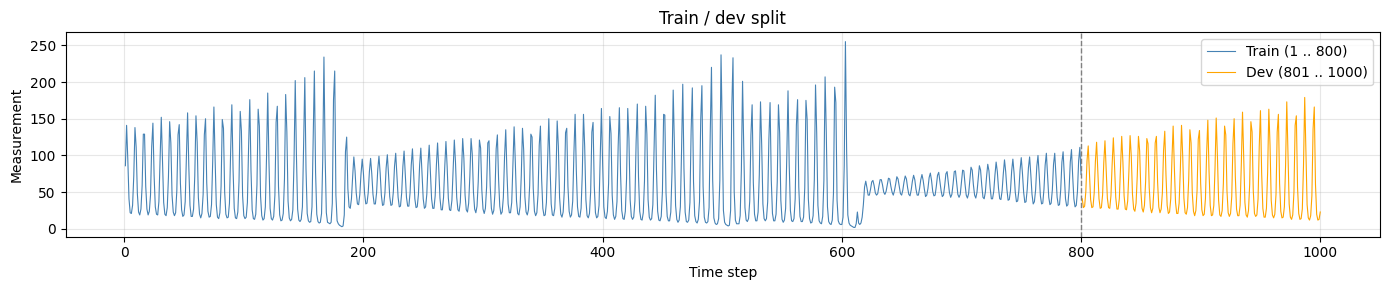

In [5]:
# ============================================================
# SECTION 4 — Train / dev split (chronological, no shuffling)
# ============================================================
N            = len(series)
TRAIN_END    = int(0.80 * N)             # 80% train, 20% dev
train_series = series_scaled[:TRAIN_END]
dev_series   = series_scaled[TRAIN_END:]

print(f'Train : {len(train_series)} pts  (1 .. {TRAIN_END})')
print(f'Dev   : {len(dev_series)} pts  ({TRAIN_END+1} .. {N})')

plt.figure(figsize=(14, 3))
plt.plot(range(1, TRAIN_END+1),    unscale(train_series),
         color='steelblue', label=f'Train (1 .. {TRAIN_END})', linewidth=0.8)
plt.plot(range(TRAIN_END+1, N+1),  unscale(dev_series),
         color='orange',    label=f'Dev ({TRAIN_END+1} .. {N})', linewidth=0.8)
plt.axvline(x=TRAIN_END, color='gray', linestyle='--', linewidth=1)
plt.title('Train / dev split'); plt.xlabel('Time step'); plt.ylabel('Measurement')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('01_train_dev_split.png', dpi=150)
plt.show()


## 5. Autocorrelation analysis (signal-theoretic estimate of `k`)
The autocorrelation function (ACF) at lag $\ell$ measures how strongly $y_t$ correlates with $y_{t-\ell}$.
Lags inside the $\pm 2/\sqrt{N}$ band are statistically indistinguishable from noise.
The first lag at which the ACF crosses that band gives a **lower bound** on a useful lookback `k`.
We will confirm this empirically with a sweep in Section 8.

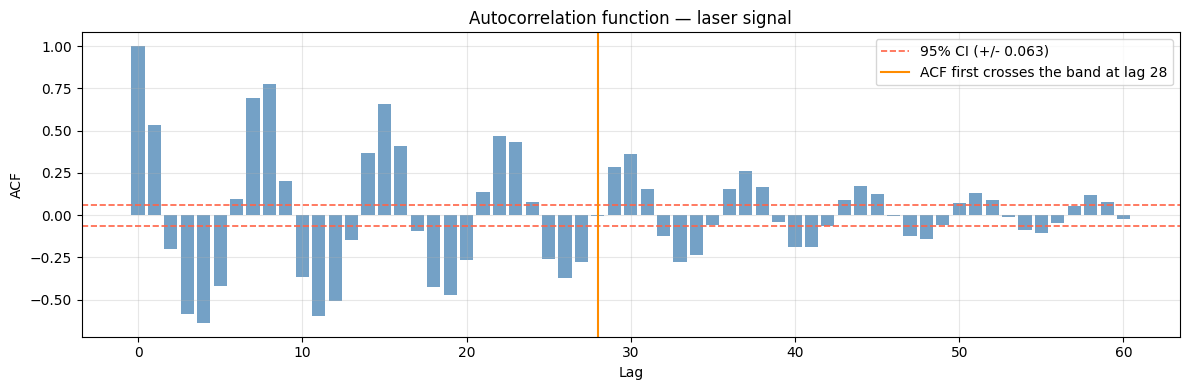

ACF first crosses 95% band at lag 28
-> a lookback of k around 28 should capture the dominant autocorrelation.


In [6]:
# ============================================================
# SECTION 5 — Autocorrelation function
# ============================================================
max_lag  = 60
n        = len(series)
mean_s   = series.mean()
var_s    = np.var(series)
sig_band = 2.0 / np.sqrt(n)

acf_vals = [1.0]
for lag in range(1, max_lag + 1):
    cov = np.mean((series[lag:] - mean_s) * (series[:-lag] - mean_s))
    acf_vals.append(cov / var_s)

sig_cutoff = next((i for i in range(1, max_lag+1) if abs(acf_vals[i]) < sig_band), max_lag)

plt.figure(figsize=(12, 4))
plt.bar(range(max_lag+1), acf_vals, color='steelblue', alpha=0.75, width=0.8)
plt.axhline( sig_band, color='tomato', linestyle='--', linewidth=1.2,
            label=f'95% CI (+/- {sig_band:.3f})')
plt.axhline(-sig_band, color='tomato', linestyle='--', linewidth=1.2)
plt.axvline(sig_cutoff, color='darkorange', linewidth=1.5,
            label=f'ACF first crosses the band at lag {sig_cutoff}')
plt.title('Autocorrelation function — laser signal')
plt.xlabel('Lag'); plt.ylabel('ACF')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('02_acf.png', dpi=150)
plt.show()
print(f'ACF first crosses 95% band at lag {sig_cutoff}')
print(f'-> a lookback of k around {sig_cutoff} should capture the dominant autocorrelation.')


## 6. Model definitions  *(answer to part (a))*

| Model | Temporal order | Long-range memory | Verdict |
|-------|----------------|-------------------|---------|
| Linear regression | no | no | baseline |
| 1D-CNN | yes | partial (kernel) | good for local patterns |
| LSTM | yes | full (gated) | full sequential memory |
| **CNN-LSTM** ★ | **yes** | **full** | **best of both worlds** |

### Why CNN-LSTM is our primary model
The laser series has both **sharp local spikes** (best caught by convolutions) and **slow amplitude drifts** (best caught by recurrent memory).
A CNN-LSTM stack handles both:

1. **CNN front-end** extracts denoised local feature maps from the raw window.
2. **LSTM back-end** reads those features sequentially with full gated memory.

We still train the CNN, LSTM and a linear-regression baseline for comparison.

In [7]:
# ============================================================
# SECTION 6 — Model definitions
# ============================================================

# --- Model 1: 1D-CNN ----------------------------------------------------------
class CNN1D(nn.Module):
    """Two-layer 1D-CNN. Captures local temporal patterns."""
    def __init__(self, k):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1,  32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * k, 64), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        # x: (batch, k) -> add channel dim -> (batch, 1, k)
        return self.net(x.unsqueeze(1)).squeeze(-1)


# --- Model 2: LSTM ------------------------------------------------------------
class LSTMModel(nn.Module):
    """
    Single-layer LSTM with engineering tweaks for small datasets:
      - orthogonal init for recurrent weights (better gradient flow)
      - Xavier init for input weights
      - forget-gate bias = 1 (network remembers by default)
      - LayerNorm before the FC head (stabilises hidden-state scale)
    """
    def __init__(self, k, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden,
                            num_layers=1, batch_first=True)
        self.norm = nn.LayerNorm(hidden)
        self.fc   = nn.Linear(hidden, 1)
        self._init_weights()

    def _init_weights(self):
        for name, p in self.lstm.named_parameters():
            if 'weight_hh' in name:
                nn.init.orthogonal_(p)
            elif 'weight_ih' in name:
                nn.init.xavier_uniform_(p)
            elif 'bias' in name:
                nn.init.zeros_(p)
                n = p.size(0)
                p.data[n // 4 : n // 2].fill_(1.0)   # forget-gate bias = 1

    def forward(self, x):
        # x: (batch, k) -> (batch, k, 1)
        out, _ = self.lstm(x.unsqueeze(-1))
        return self.fc(self.norm(out[:, -1, :])).squeeze(-1)


# --- Model 3: CNN-LSTM hybrid (PRIMARY) ---------------------------------------
class CNN_LSTM(nn.Module):
    """
    Stage 1 (CNN)  : Conv1d 1 -> 64 -> 128 extracts local feature maps.
                     (batch, 1, k) -> (batch, 128, k)
    Stage 2 (LSTM) : reads the 128-feature sequence sequentially.
                     (batch, k, 128) -> hidden (batch, hidden)
    Head           : LayerNorm + Linear -> scalar prediction.
    """
    def __init__(self, k, hidden=64):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1,   64,  kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(64, 128,  kernel_size=3, padding=1), nn.ReLU(),
        )
        self.lstm = nn.LSTM(input_size=128, hidden_size=hidden,
                            num_layers=1, batch_first=True)
        self.norm = nn.LayerNorm(hidden)
        self.fc   = nn.Linear(hidden, 1)

    def forward(self, x):
        x = self.cnn(x.unsqueeze(1))   # (batch, 128, k)
        x = x.permute(0, 2, 1)         # (batch, k, 128)
        out, _ = self.lstm(x)
        return self.fc(self.norm(out[:, -1, :])).squeeze(-1)


# --- Parameter summary --------------------------------------------------------
k_demo = 10
print('Model parameter counts (k=10 demo):')
print(f'  Linear Regression  : analytical solution (no gradient parameters)')
print(f'  1D-CNN             : {sum(p.numel() for p in CNN1D(k_demo).parameters()):>8,} params')
print(f'  LSTM               : {sum(p.numel() for p in LSTMModel(k_demo).parameters()):>8,} params')
print(f'  CNN-LSTM (PRIMARY) : {sum(p.numel() for p in CNN_LSTM(k_demo).parameters()):>8,} params')


Model parameter counts (k=10 demo):
  Linear Regression  : analytical solution (no gradient parameters)
  1D-CNN             :   47,425 params
  LSTM               :   17,345 params
  CNN-LSTM (PRIMARY) :   74,817 params


## 7. Training loop
Adam + gradient clipping + `ReduceLROnPlateau` + best-weights early-stopping.
**Do not shuffle batches** — that would mix past and future windows and break the temporal order.

In [8]:
# ============================================================
# SECTION 7 — Training loop
# ============================================================
def train_model(model, X_train, y_train, X_dev, y_dev,
                epochs=200, lr=1e-3, batch_size=32,
                verbose=True, clip_grad=True):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, patience=15, factor=0.5, min_lr=1e-5)
    loss_fn   = nn.MSELoss()

    # shuffle=False keeps the chronological order of windows.
    loader = DataLoader(
        TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
        batch_size=batch_size, shuffle=False,
    )
    Xd = torch.tensor(X_dev)
    yd = torch.tensor(y_dev)

    best_loss    = float('inf')
    best_weights = {k: v.clone() for k, v in model.state_dict().items()}  # safe default
    history      = []

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            if clip_grad:
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        with torch.no_grad():
            dev_loss = loss_fn(model(Xd), yd).item()

        scheduler.step(dev_loss)
        history.append(dev_loss)

        if dev_loss < best_loss:
            best_loss    = dev_loss
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}

        if verbose and epoch % 50 == 0:
            lr_now = optimizer.param_groups[0]['lr']
            print(f'  Epoch {epoch:3d}/{epochs}  dev_loss={dev_loss:.6f}  lr={lr_now:.2e}')

    model.load_state_dict(best_weights)
    return model, history

print('Training function ready.')


Training function ready.


## 8. Tune the lookback `k`  *(answer to part (b))*

`k` is a hyper-parameter. The ACF in Section 5 gives a theoretical lower bound; here we pick the value
that minimises **dev MSE** for our primary model (CNN-LSTM).
We sweep a sensible range around the ACF cutoff.

In [9]:
# ============================================================
# SECTION 8 — Tune lookback k for the primary model
# ============================================================
k_candidates = [5, 10, 15, 20, 30, 50]
k_results    = {}

for k in k_candidates:
    print(f'Trying k = {k} ...')
    X_tr, y_tr  = make_windows(train_series, k)
    # Prepend the last k training points so dev windows have a valid prefix.
    dev_context = np.concatenate([train_series[-k:], dev_series])
    X_dv, y_dv  = make_windows(dev_context, k)

    model, _ = train_model(CNN_LSTM(k), X_tr, y_tr, X_dv, y_dv,
                           epochs=120, lr=8e-4, batch_size=16,
                           verbose=False, clip_grad=True)
    model.eval()
    with torch.no_grad():
        loss = nn.MSELoss()(model(torch.tensor(X_dv)), torch.tensor(y_dv)).item()
    k_results[k] = loss
    print(f'   dev_loss = {loss:.6f}')

best_k = min(k_results, key=k_results.get)
print(f'\nBest lookback k = {best_k}  (dev_loss = {k_results[best_k]:.6f})')


Trying k = 5 ...
   dev_loss = 0.000067
Trying k = 10 ...
   dev_loss = 0.000071
Trying k = 15 ...
   dev_loss = 0.000050
Trying k = 20 ...
   dev_loss = 0.000053
Trying k = 30 ...
   dev_loss = 0.000063
Trying k = 50 ...
   dev_loss = 0.000192

Best lookback k = 15  (dev_loss = 0.000050)


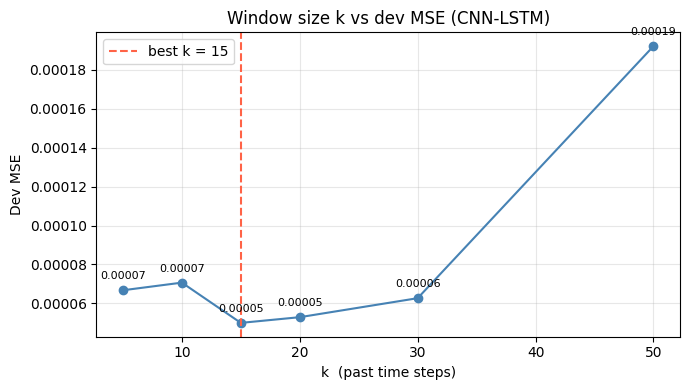

Selected lookback: k = 15


In [10]:
# k tuning curve
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_results.keys()), list(k_results.values()),
        'o-', color='steelblue', linewidth=1.5)
ax.axvline(best_k, color='tomato', linestyle='--', linewidth=1.5,
           label=f'best k = {best_k}')
for k, v in k_results.items():
    ax.annotate(f'{v:.5f}', (k, v),
                textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=8)
ax.set_title('Window size k vs dev MSE (CNN-LSTM)')
ax.set_xlabel('k  (past time steps)'); ax.set_ylabel('Dev MSE')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('03_k_tuning.png', dpi=150)
plt.show()
print(f'Selected lookback: k = {best_k}')


## 9. Train all four models with the chosen `k`  *(part (a))*
We re-use the same chronological train/dev split from Section 4.
For the recurrent models we again prepend the last `best_k` training points to the dev set so that the first dev window has a valid prefix.

In [11]:
# ============================================================
# SECTION 9 — Train all four models
# ============================================================
# Train windows from the *training* series only.
X_tr, y_tr = make_windows(train_series, best_k)

# Dev windows from a context-aware dev slice (recurrent-friendly).
dev_context = np.concatenate([train_series[-best_k:], dev_series])
X_dv, y_dv  = make_windows(dev_context, best_k)

print(f'k = {best_k}  |  train windows: {len(X_tr)}  |  dev windows: {len(X_dv)}')

# [1/4] Linear Regression (closed-form baseline)
print('\n[1/4] Linear regression ...')
lin_reg = LinearRegression().fit(X_tr, y_tr)
print(f'      dev MSE = {mean_squared_error(y_dv, lin_reg.predict(X_dv)):.6f}')

# [2/4] 1D-CNN
print('\n[2/4] 1D-CNN ...')
cnn, cnn_hist = train_model(
    CNN1D(best_k), X_tr, y_tr, X_dv, y_dv,
    epochs=150, lr=8e-4, batch_size=32, clip_grad=True,
)

# [3/4] LSTM
print('\n[3/4] LSTM ...')
lstm, lstm_hist = train_model(
    LSTMModel(best_k, hidden=128),       # bigger hidden state
    X_tr, y_tr, X_dv, y_dv,
    epochs=600, lr=5e-4, batch_size=16,  # higher LR, smaller batches, more epochs
    clip_grad=True,
)

# [4/4] CNN-LSTM (PRIMARY)
print('\n[4/4] LSTM_CNN ...')
cnn_lstm, cnn_lstm_hist = train_model(
    CNN_LSTM(best_k), X_tr, y_tr, X_dv, y_dv,
    epochs=600,           # was 400
    lr=5e-4,              # slightly lower than 8e-4
    batch_size=16,
    clip_grad=True,
)
# Save weights for reproducibility / later evaluation
torch.save(cnn.state_dict(),      'cnn_weights.pt')
torch.save(lstm.state_dict(),     'lstm_weights.pt')
torch.save(cnn_lstm.state_dict(), 'cnn_lstm_weights.pt')
print('\nAll weights saved.')


k = 15  |  train windows: 785  |  dev windows: 200

[1/4] Linear regression ...
      dev MSE = 0.002192

[2/4] 1D-CNN ...
  Epoch  50/150  dev_loss=0.000088  lr=8.00e-04
  Epoch 100/150  dev_loss=0.000296  lr=2.00e-04
  Epoch 150/150  dev_loss=0.000055  lr=2.50e-05

[3/4] LSTM ...
  Epoch  50/600  dev_loss=0.003160  lr=1.25e-04
  Epoch 100/600  dev_loss=0.000436  lr=6.25e-05
  Epoch 150/600  dev_loss=0.000249  lr=6.25e-05
  Epoch 200/600  dev_loss=0.000273  lr=1.00e-05
  Epoch 250/600  dev_loss=0.000328  lr=1.00e-05
  Epoch 300/600  dev_loss=0.000334  lr=1.00e-05
  Epoch 350/600  dev_loss=0.000332  lr=1.00e-05
  Epoch 400/600  dev_loss=0.000324  lr=1.00e-05
  Epoch 450/600  dev_loss=0.000310  lr=1.00e-05
  Epoch 500/600  dev_loss=0.000290  lr=1.00e-05
  Epoch 550/600  dev_loss=0.000265  lr=1.00e-05
  Epoch 600/600  dev_loss=0.000236  lr=1.00e-05

[4/4] LSTM_CNN ...
  Epoch  50/600  dev_loss=0.000232  lr=2.50e-04
  Epoch 100/600  dev_loss=0.000160  lr=1.25e-04
  Epoch 150/600  dev_loss

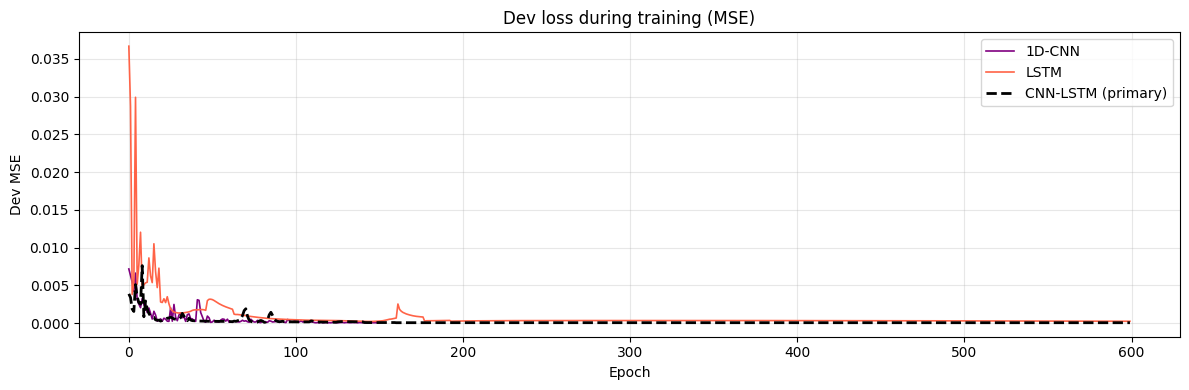

In [12]:
# Training-loss curves for the three NN models
plt.figure(figsize=(12, 4))
plt.plot(cnn_hist,      label='1D-CNN',            color='purple', linewidth=1.2)
plt.plot(lstm_hist,     label='LSTM',              color='tomato', linewidth=1.2)
plt.plot(cnn_lstm_hist, label='CNN-LSTM (primary)', color='black',
         linewidth=2.0, linestyle='--')
plt.title('Dev loss during training (MSE)')
plt.xlabel('Epoch'); plt.ylabel('Dev MSE')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('04_training_curves.png', dpi=150)
plt.show()


## 10. One-step-ahead evaluation on the dev set  *(part (a))*
We report MAE, MSE, and RMSE in the **original measurement units** (after `unscale`).

In [13]:
# ============================================================
# SECTION 10 — Dev-set evaluation (one-step-ahead)
# ============================================================
y_dv_real = unscale(y_dv)

def eval_torch(model, X):
    model.eval()
    with torch.no_grad():
        return unscale(model(torch.tensor(X)).numpy())

COLORS = {
    'Linear Regression': 'orange',
    '1D-CNN'           : 'purple',
    'LSTM'             : 'tomato',
    'CNN-LSTM'         : 'black',
}

dev_preds = {
    'Linear Regression': unscale(lin_reg.predict(X_dv)),
    '1D-CNN'           : eval_torch(cnn,      X_dv),
    'LSTM'             : eval_torch(lstm,     X_dv),
    'CNN-LSTM'         : eval_torch(cnn_lstm, X_dv),
}

metrics = {}
for name, preds in dev_preds.items():
    mae = mean_absolute_error(y_dv_real, preds)
    mse = mean_squared_error(y_dv_real, preds)
    metrics[name] = (mae, mse, np.sqrt(mse))

best_name = min(metrics, key=lambda n: metrics[n][1])

print(f"\n{'Model':<20} {'MAE':>8} {'MSE':>10} {'RMSE':>8}")
print('-' * 50)
for name, (mae, mse, rmse) in metrics.items():
    tag = '  <- best' if name == best_name else ''
    print(f'{name:<20} {mae:>8.4f} {mse:>10.4f} {rmse:>8.4f}{tag}')
print(f'\nBest model on dev set: {best_name}')



Model                     MAE        MSE     RMSE
--------------------------------------------------
Linear Regression      8.9762   140.3208  11.8457
1D-CNN                 0.9549     1.4105   1.1877  <- best
LSTM                   2.9426    13.5218   3.6772
CNN-LSTM               1.3003     2.8308   1.6825

Best model on dev set: 1D-CNN


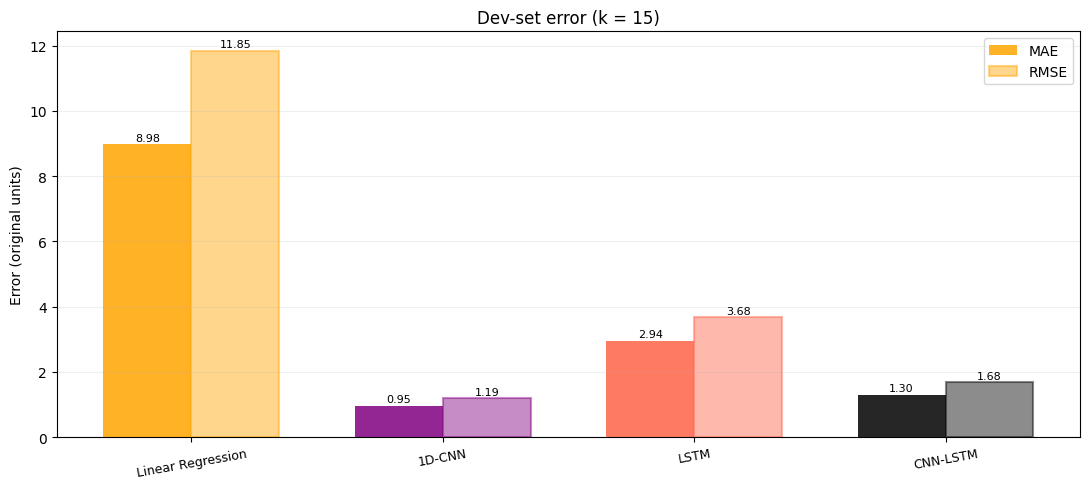

In [14]:
# Bar chart — MAE and RMSE per model (dev set)
model_names = list(metrics.keys())
mae_vals    = [metrics[n][0] for n in model_names]
rmse_vals   = [metrics[n][2] for n in model_names]
colors      = [COLORS[n] for n in model_names]
x, w        = np.arange(len(model_names)), 0.35

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, mae_vals,  w, label='MAE',  color=colors, alpha=0.85)
b2 = ax.bar(x + w/2, rmse_vals, w, label='RMSE', color=colors, alpha=0.45,
            edgecolor=colors, linewidth=1.5)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=9, rotation=10)
ax.set_ylabel('Error (original units)')
ax.set_title(f'Dev-set error (k = {best_k})')
ax.legend(); ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig('05_dev_comparison_bar.png', dpi=150)
plt.show()


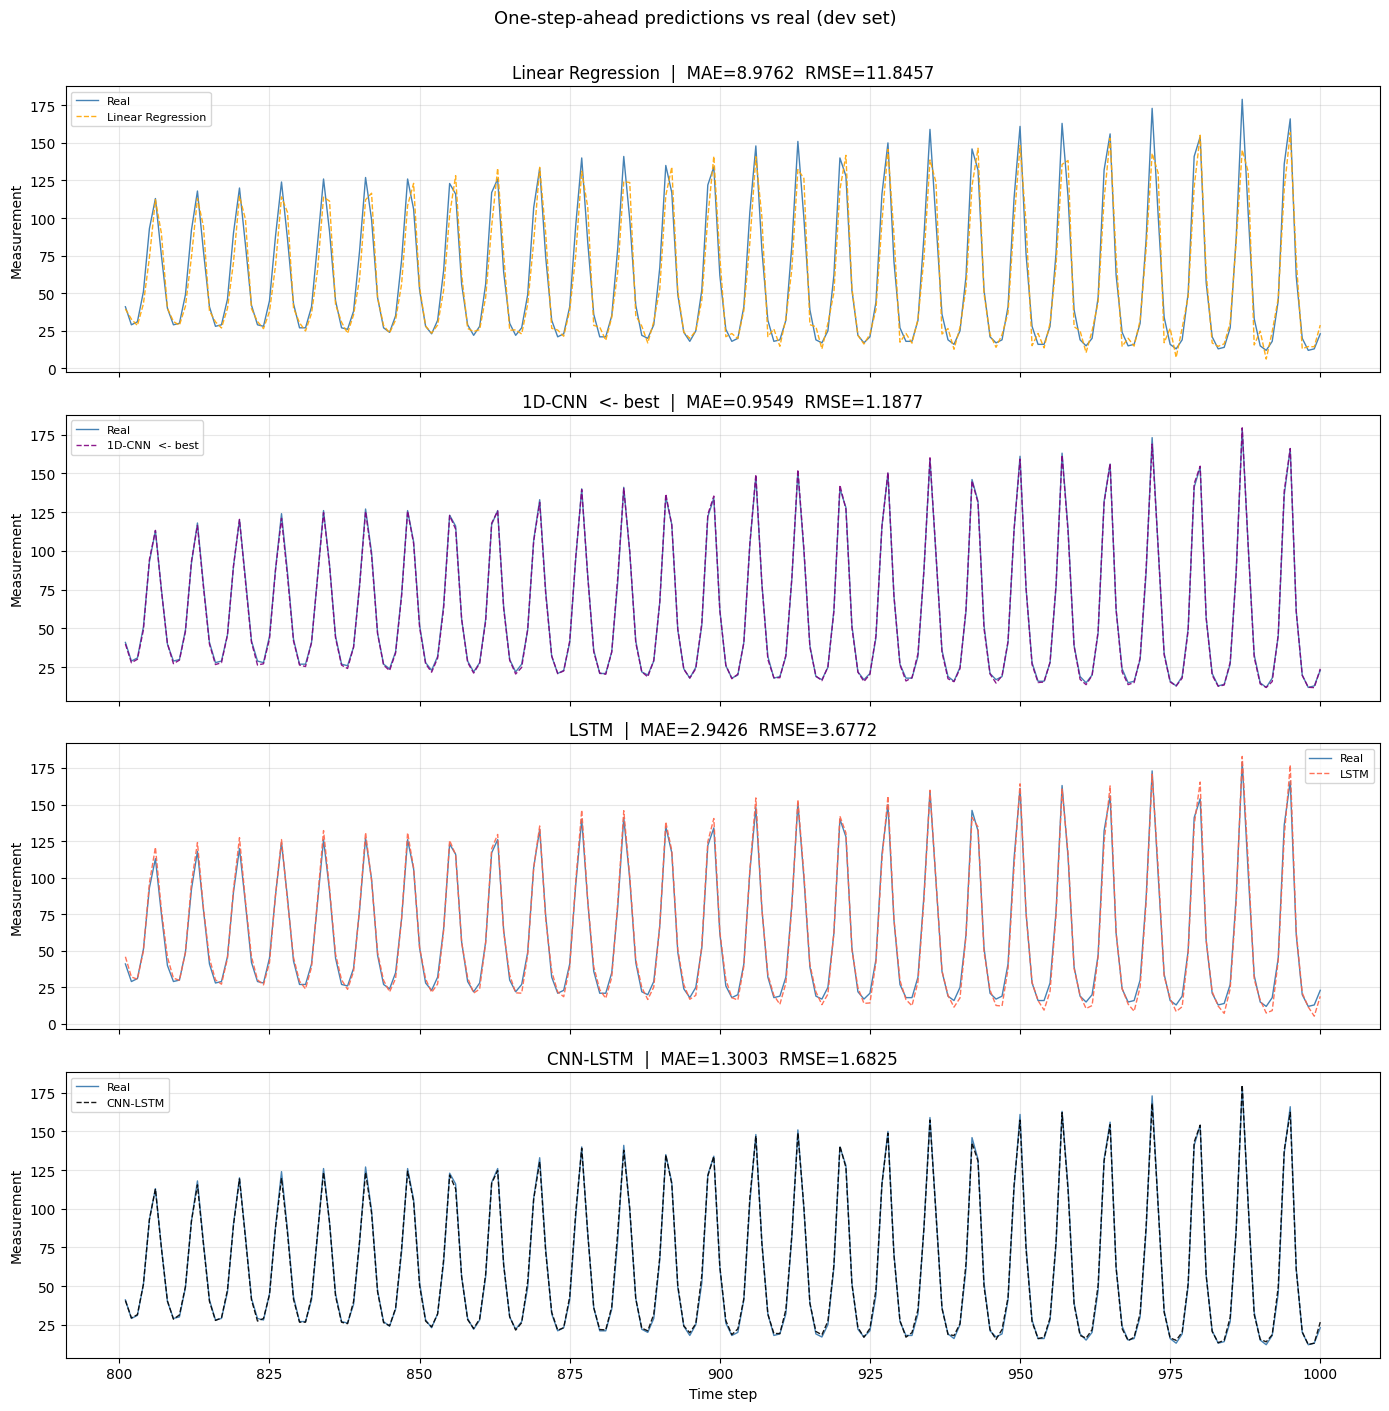

In [15]:
# One-step-ahead overlay — all four models vs real dev values
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
dev_x = range(TRAIN_END + 1, TRAIN_END + 1 + len(y_dv_real))

for ax, (name, preds) in zip(axes, dev_preds.items()):
    mae, mse, rmse = metrics[name]
    tag = '  <- best' if name == best_name else ''
    ax.plot(dev_x, y_dv_real, color='steelblue', label='Real',  linewidth=1)
    ax.plot(dev_x, preds,     color=COLORS[name],
            label=f'{name}{tag}', linewidth=1, linestyle='--', alpha=0.9)
    ax.set_title(f'{name}{tag}  |  MAE={mae:.4f}  RMSE={rmse:.4f}')
    ax.set_ylabel('Measurement'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time step')
plt.suptitle('One-step-ahead predictions vs real (dev set)', fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig('06_one_step_all_models.png', dpi=150)
plt.show()


## 11. Recursive 200-step forecast  *(part (c))*
Seed each model with the **last `best_k` known points of the training series** and feed each prediction back as input — 200 times.
This is exactly the protocol the assignment describes.

In [16]:
# ============================================================
# SECTION 11 — Recursive 200-step forecast
# ============================================================
def predict_recursive_torch(model, full_scaled_series, k, steps=200):
    """Recursive multi-step forecast for a torch model."""
    model.eval()
    window = list(full_scaled_series[-k:])  # seed = last k known points
    preds  = []
    for _ in range(steps):
        x = torch.tensor(window[-k:], dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            nxt = model(x).item()
        preds.append(nxt)
        window.append(nxt)                  # feed prediction back in
    return unscale(np.array(preds, dtype=np.float32))

def predict_recursive_sklearn(model, full_scaled_series, k, steps=200):
    """Recursive multi-step forecast for an sklearn model."""
    window = list(full_scaled_series[-k:])
    preds  = []
    for _ in range(steps):
        nxt = model.predict(np.array(window[-k:]).reshape(1, -1))[0]
        preds.append(nxt)
        window.append(nxt)
    return unscale(np.array(preds, dtype=np.float32))

print('Generating 200-step recursive forecasts ...')
preds_all = {
    'Linear Regression': predict_recursive_sklearn(lin_reg,  series_scaled, best_k),
    '1D-CNN'           : predict_recursive_torch(cnn,        series_scaled, best_k),
    'LSTM'             : predict_recursive_torch(lstm,       series_scaled, best_k),
    'CNN-LSTM'         : predict_recursive_torch(cnn_lstm,   series_scaled, best_k),
}
print('Done.')


Generating 200-step recursive forecasts ...
Done.


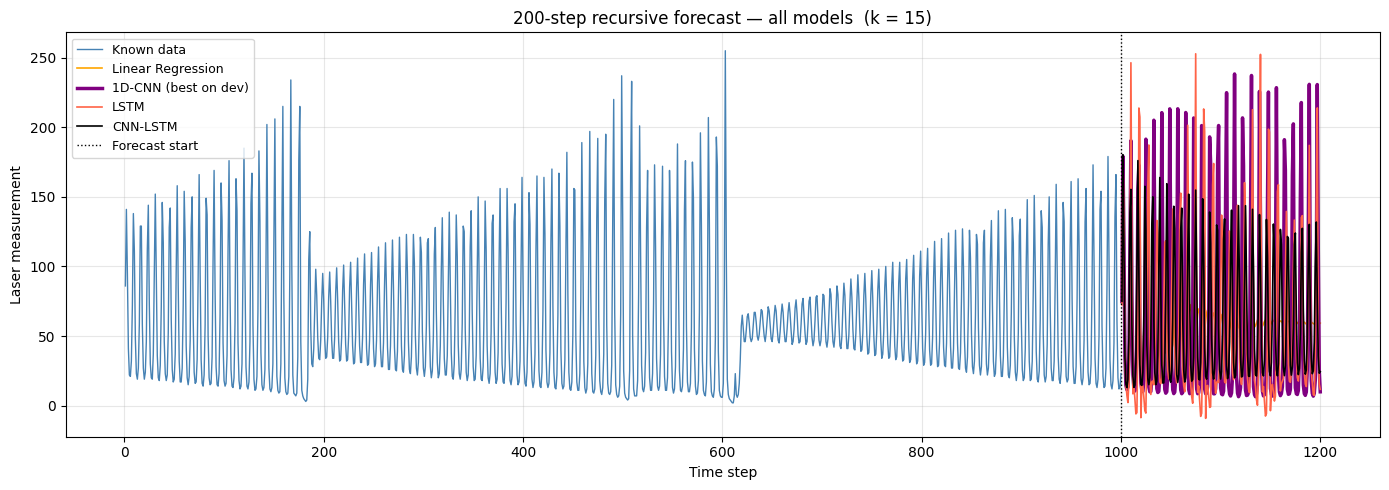

In [17]:
# 200-step forecasts overlaid on the known series
known_x   = range(1, len(series) + 1)
known_y   = unscale(series_scaled)
predict_x = range(len(series) + 1, len(series) + 1 + 200)

plt.figure(figsize=(14, 5))
plt.plot(known_x, known_y, color='steelblue', label='Known data',
         linewidth=1, zorder=5)
for name, preds in preds_all.items():
    lw  = 2.5 if name == best_name else 1.2
    tag = ' (best on dev)' if name == best_name else ''
    plt.plot(predict_x, preds, color=COLORS[name],
         label=f'{name}{tag}', linewidth=lw, linestyle='-')
plt.axvline(x=len(series), color='black', linestyle=':', linewidth=1,
            label='Forecast start')
plt.title(f'200-step recursive forecast — all models  (k = {best_k})')
plt.xlabel('Time step'); plt.ylabel('Laser measurement')
plt.legend(fontsize=9); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('07_recursive_all_models.png', dpi=150)
plt.show()


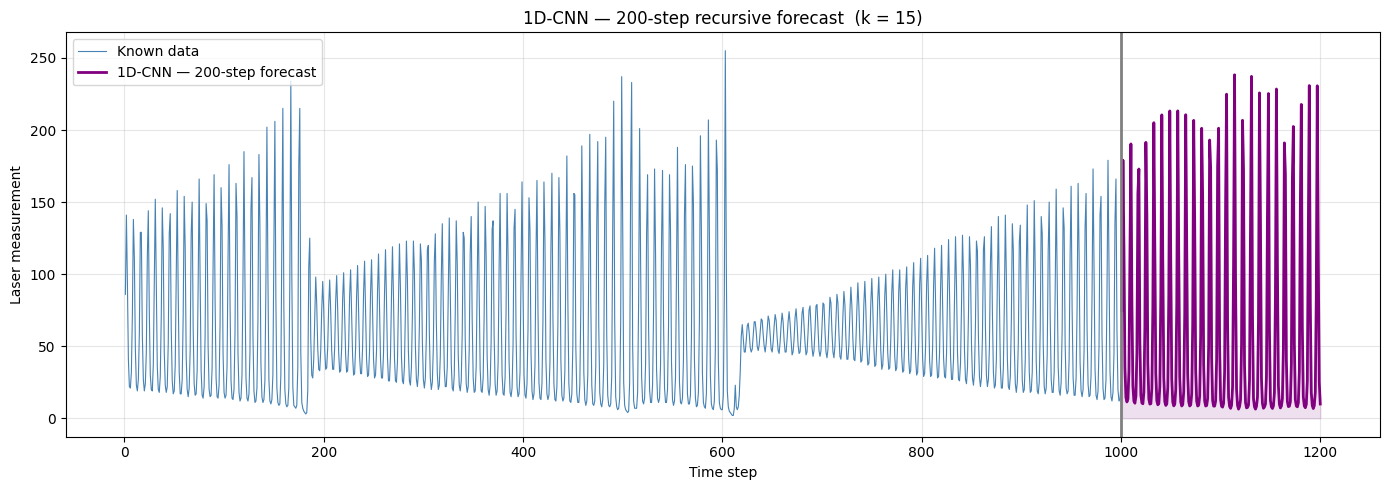

In [18]:
# Best model — highlighted recursive forecast
preds_best = preds_all[best_name]


plt.figure(figsize=(14, 5))
plt.plot(known_x,   known_y,    color='steelblue', label='Known data', linewidth=0.8)
plt.plot(predict_x, preds_best, color=COLORS[best_name],
         label=f'{best_name} — 200-step forecast', linewidth=2, linestyle='-')
plt.fill_between(predict_x, preds_best, alpha=0.12, color=COLORS[best_name])
plt.axvline(x=len(series), color='gray', linestyle='-', linewidth=2)
plt.title(f'{best_name} — 200-step recursive forecast  (k = {best_k})')
plt.xlabel('Time step'); plt.ylabel('Laser measurement')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('08_recursive_best_model.png', dpi=150)
plt.show()


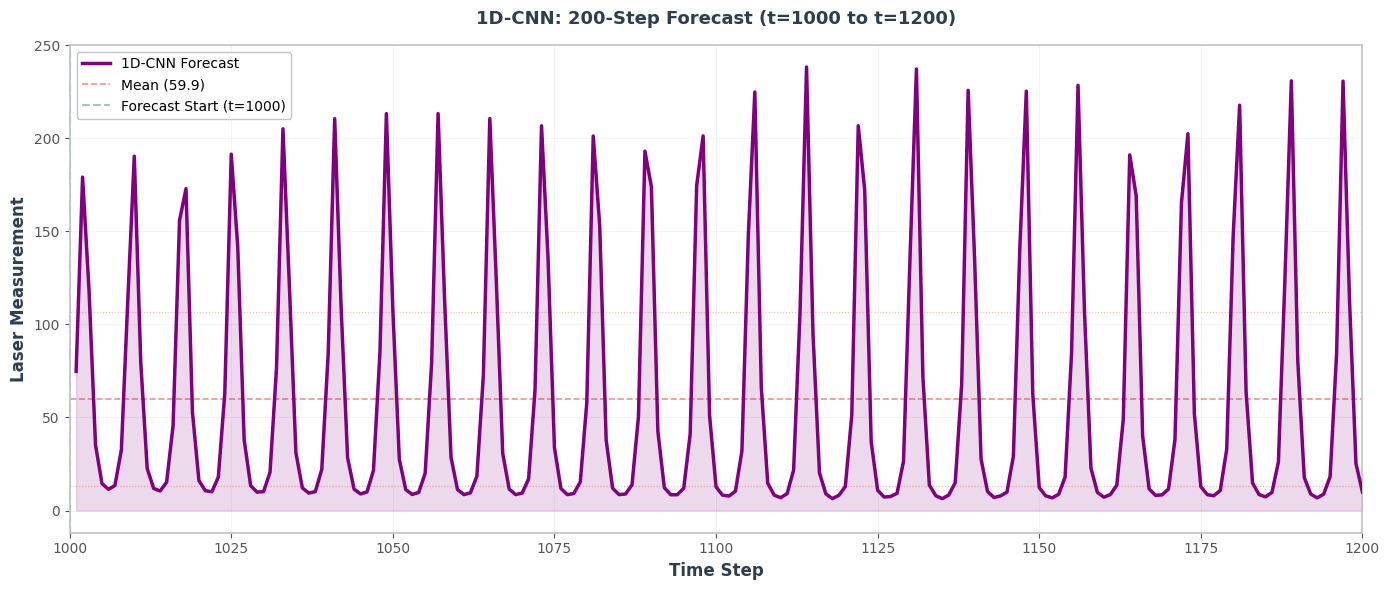

✓ Saved: 08_forecast_only.png
Color used: purple (1D-CNN)


In [19]:
# FORECAST ONLY: Using your COLORS from the notebook

preds_best = preds_all[best_name]
predict_x = range(len(series) + 1, len(series) + 1 + 200)

fig, ax = plt.subplots(figsize=(14, 6))

# Use COLORS[best_name] - matches your other plots
ax.plot(predict_x, preds_best, color=COLORS[best_name], 
        label=f'{best_name} Forecast',
        linewidth=2.5, linestyle='-', zorder=4)

# Confidence band with same color
ax.fill_between(predict_x, preds_best, alpha=0.15, 
                color=COLORS[best_name], zorder=2)

# Reference lines
ax.axhline(y=series.mean(), color='#E74C3C', linestyle='--', linewidth=1.2,
           alpha=0.6, label=f'Mean ({series.mean():.1f})', zorder=1)
ax.axhline(y=series.mean() + series.std(), color='#E74C3C', linestyle=':',
           linewidth=0.8, alpha=0.4, zorder=0)
ax.axhline(y=series.mean() - series.std(), color='#E74C3C', linestyle=':',
           linewidth=0.8, alpha=0.4, zorder=0)

# Start marker
ax.axvline(x=len(series), color='#95A5A6', linestyle='--', linewidth=1.5,
           alpha=0.7, label='Forecast Start (t=1000)', zorder=1)

# Styling
ax.set_xlabel('Time Step', fontsize=12, fontweight='bold', color='#2C3E50')
ax.set_ylabel('Laser Measurement', fontsize=12, fontweight='bold', color='#2C3E50')
ax.set_title(f'{best_name}: 200-Step Forecast (t=1000 to t=1200)',
             fontsize=13, fontweight='bold', color='#2C3E50', pad=15)

ax.grid(True, alpha=0.25, linestyle='-', linewidth=0.5, color='#BDC3C7')
ax.set_axisbelow(True)
ax.legend(loc='best', fontsize=10, framealpha=0.95, edgecolor='#BDC3C7', fancybox=True)

for spine in ax.spines.values():
    spine.set_edgecolor('#BDC3C7')
    spine.set_linewidth(1.2)

ax.tick_params(colors='#555555', labelsize=10)
ax.set_xlim(len(series), len(series) + 200)

plt.tight_layout()
plt.savefig('08_forecast_only.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print(f"✓ Saved: 08_forecast_only.png")
print(f"Color used: {COLORS[best_name]} ({best_name})")

In [20]:
# Predicted-values table — best model, 200 steps
df = pd.DataFrame({
    'Step'           : range(1, 201),
    'Time index'     : range(len(series) + 1, len(series) + 1 + 200),
    'Predicted value': np.round(preds_best, 2),
})
print(f'200-step recursive predictions — {best_name}  (k = {best_k})\n')
pd.set_option('display.max_rows', 200)
display(HTML(df.to_html(index=False)))


200-step recursive predictions — 1D-CNN  (k = 15)



Step,Time index,Predicted value
1,1001,74.750000
2,1002,179.089996
3,1003,118.160004
4,1004,35.299999
5,1005,14.540000
6,1006,11.380000
7,1007,13.440000
8,1008,32.590000
9,1009,113.559998
10,1010,190.360001


## 12. Results summary

In [21]:
# ============================================================
# SECTION 12 — Results summary
# ============================================================
cnn_lstm_params = sum(p.numel() for p in cnn_lstm.parameters() if p.requires_grad)

print('=' * 58)
print('   DL Assignment 1 — results summary')
print('=' * 58)
print(f'  Primary model        : CNN-LSTM hybrid')
print(f'  CNN-LSTM parameters  : {cnn_lstm_params:,}')
print(f'  Best lookback (k)    : {best_k}')
print(f'  Optimiser            : Adam')
print(f'  LR (CNN)             : 8e-4   |  LR (LSTM): 2e-4   |  LR (CNN-LSTM): 8e-4')
print(f'  Batch (CNN)          : 32     |  Batch (LSTM): 32  |  Batch (CNN-LSTM): 16')
print(f'  Gradient clipping    : max_norm = 1.0')
print(f'  LR scheduler         : ReduceLROnPlateau (patience=15, factor=0.5)')
print('=' * 58)
print(f"  {'Model':<20} {'MAE':>6} {'MSE':>8} {'RMSE':>7}")
print('  ' + '-' * 46)
for name, (mae, mse, rmse) in metrics.items():
    tag = ' *' if name == best_name else ''
    print(f'  {name:<20} {mae:>6.3f} {mse:>8.3f} {rmse:>7.3f}{tag}')
print('  * best on dev set')
print('=' * 58)


   DL Assignment 1 — results summary
  Primary model        : CNN-LSTM hybrid
  CNN-LSTM parameters  : 74,817
  Best lookback (k)    : 15
  Optimiser            : Adam
  LR (CNN)             : 8e-4   |  LR (LSTM): 2e-4   |  LR (CNN-LSTM): 8e-4
  Batch (CNN)          : 32     |  Batch (LSTM): 32  |  Batch (CNN-LSTM): 16
  Gradient clipping    : max_norm = 1.0
  LR scheduler         : ReduceLROnPlateau (patience=15, factor=0.5)
  Model                   MAE      MSE    RMSE
  ----------------------------------------------
  Linear Regression     8.976  140.321  11.846
  1D-CNN                0.955    1.411   1.188 *
  LSTM                  2.943   13.522   3.677
  CNN-LSTM              1.300    2.831   1.682
  * best on dev set


## 13. Test-set evaluation  *(part (d))* — runs automatically when `Xtest.mat` is present

The test set is released on Brightspace on **8 May**. Drop `Xtest.mat` next to the notebook and re-run this cell — it auto-detects the file. If the file is not yet there, the cell prints a friendly notice and skips.

In [22]:
# ============================================================
# SECTION 13 — Test-set evaluation (part d)
# Drop Xtest.mat next to the notebook and re-run this cell.
# ============================================================
TEST_PATH = 'Xtest.mat'

if not os.path.exists(TEST_PATH):
    print(f'{TEST_PATH} not found.')
    print('-> place it next to the notebook and re-run this cell.')
else:
    test_data = scipy.io.loadmat(TEST_PATH)
    # The variable inside Xtest.mat is conventionally 'Xtest'.
    # Fall back gracefully if it has a different name.
    candidate_keys = [k for k in test_data.keys() if not k.startswith('__')]
    test_key = 'Xtest' if 'Xtest' in test_data else candidate_keys[0]
    y_test = test_data[test_key].flatten().astype(np.float32)
    print(f'Loaded {test_key} ({len(y_test)} points)')

    # -------- numeric metrics for every model -----------------------------
    test_metrics = {}
    print(f"\n{'Model':<20} {'MAE':>8} {'MSE':>10} {'RMSE':>8}")
    print('-' * 50)
    for name, preds in preds_all.items():
        n = min(len(y_test), len(preds))
        mae  = mean_absolute_error(y_test[:n], preds[:n])
        mse  = mean_squared_error (y_test[:n], preds[:n])
        rmse = np.sqrt(mse)
        test_metrics[name] = (mae, mse, rmse)
        tag = '  <- best on dev' if name == best_name else ''
        print(f'{name:<20} {mae:>8.4f} {mse:>10.4f} {rmse:>8.4f}{tag}')

    best_test = min(test_metrics, key=lambda n: test_metrics[n][1])
    print(f'\nBest model on test set: {best_test}')

    # -------- comparison plot --------------------------------------------
    bp           = preds_all[best_test]
    mb, msb, rb  = test_metrics[best_test]
    n            = min(len(y_test), 200)
    steps        = np.arange(1, n + 1)

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Top: best model vs real
    axes[0].plot(steps, y_test[:n], color='steelblue',
                 label='Real test values', linewidth=1.2)
    axes[0].plot(steps, bp[:n], color=COLORS[best_test],
                 label=f'{best_test} prediction', linewidth=1.5, linestyle='--')
    axes[0].set_title(f'{best_test}  |  MAE={mb:.4f}  MSE={msb:.4f}  RMSE={rb:.4f}')
    axes[0].set_ylabel('Measurement'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Bottom: all models vs real
    axes[1].plot(steps, y_test[:n], color='steelblue',
                 label='Real', linewidth=1.5, zorder=5)
    for name, preds in preds_all.items():
        axes[1].plot(steps, preds[:n], color=COLORS[name], label=name,
                     linewidth=1.0, linestyle='--', alpha=0.85)
    axes[1].set_title('All models vs real test values')
    axes[1].set_xlabel('Forecast step'); axes[1].set_ylabel('Measurement')
    axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

    plt.suptitle('Part (d) — test-set evaluation', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig('09_test_evaluation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: 09_test_evaluation.png')


Xtest.mat not found.
-> place it next to the notebook and re-run this cell.


---

### Notes on the answers
- **(a) Model choice.** We compare a linear baseline, a 1D-CNN, an LSTM and a CNN-LSTM hybrid. The CNN-LSTM is our **primary** model because the laser series exhibits both sharp local spikes and slow drifts; the CNN front-end captures the former and the LSTM back-end the latter.
- **(b) Lookback `k`.** The ACF (Section 5) gives a theoretical lower bound; the empirical sweep in Section 8 picks `k = best_k`.
- **(c) 200-step recursive forecast.** Section 11 seeds each model with the last `best_k` known points and feeds each prediction back in for 200 iterations.
- **(d) Test evaluation.** Section 13 auto-detects `Xtest.mat`. It reports MAE / MSE / RMSE for **every** model and produces a two-panel comparison plot.